In [148]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_simulation, plot_results
import pandas as pd
from laboneq_applications.experiments import (
    qubit_spectroscopy,
    qubit_spectroscopy_amplitude,
)

print(laboneq.__version__)

2.51.0


In [149]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.24 19:07:15.219] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.24 19:07:15.222] INFO    VERSION: laboneq 2.51.0
[2025.08.24 19:07:15.223] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 19:07:15.227] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004


[2025.08.24 19:07:15.233] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.24 19:07:15.238] INFO    Configuring the device setup
[2025.08.24 19:07:15.245] INFO    The device setup is configured


In [198]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.4e9
res_freq = 7.23025e9
start_freq = -27e6  # actual_start_freq = central_freq - start_freq
stop_freq = -24e6
num_points = 401  # stop - start / (num_points-1)
integration_time = 1e-5
num_averages = 12  # average number = 2^n, n_max = 17
drive_range = -10
drive_pulse_amp = 0.8
drive_pulse_length = 5e-6
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9
ro_pulse_length = 5e-6
ro_pulse_amp = 0.1

In [199]:
# pulse parameters and definitions
def create_readout_pulse(
    qubit, length=ro_pulse_length, amplitude=ro_pulse_amp):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude)
    return readout_pulse

def create_drive_pulse(qubit, length=drive_pulse_length, amplitude=drive_pulse_amp):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude)
    return pulse

def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [200]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter 
def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse): # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines 
    exp_qspec = Experiment( uid="Qubit Spectroscopy", signals=[ ExperimentSignal("drive"), ExperimentSignal("measure"), ExperimentSignal("acquire"), ], ) 
    # inner loop - real-time averaging - QA in integration mode 
    with exp_qspec.acquire_loop_rt( uid="freq_shots", count=2**num_averages, acquisition_type=AcquisitionType.SPECTROSCOPY, ): 
        
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep, reset_oscillator_phase = True): 
            # qubit drive 
            with exp_qspec.section(uid="qubit_excitation"): exp_qspec.play(signal="drive", pulse=drive_pulse) 
            with exp_qspec.section( uid="readout_section", play_after="qubit_excitation" ): 
                # play readout pulse on measure line 
                exp_qspec.play(signal="measure", pulse=readout_pulse, length = integration_time) 
                # trigger signal data acquisition 
                exp_qspec.measure( acquire_signal="acquire", integration_length = integration_time, handle="qb_spec", reset_delay = 1e-6 ) 
                # relax time after readout - for qubit relaxation to groundstate and signal processing 
            with exp_qspec.section(uid="relax", length=100e-6):
                exp_qspec.reserve(signal="measure") 
                exp_qspec.reserve(signal='acquire') 
    return exp_qspec

In [201]:

freq_sweep_q0 = create_drive_freq_sweep("q0", start_freq, stop_freq, num_points)


# signal map for qubit 0
def signal_map_default(q0):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range, 
)
# exp_calibration["twpa_pump"] = SignalCalibration(
#     oscillator = Oscillator(uid = "twpa_pump_osc", frequency = pump_fre,
#         modulation_type=ModulationType.HARDWARE
#     ),
#     local_oscillator = Oscillator(uid="twpa_lo", frequency = pump_fre_lo),
#     range = pump_range,
# )
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range,
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range,
)

# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_pulse("q0")
readout_pulse = create_readout_pulse("q0")

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration)
exp_qspec.set_signal_map(signal_map_default("q0"))

[2025.08.24 19:44:05.450] INFO    Starting LabOne Q Compiler run...
[2025.08.24 19:44:05.454] INFO    Phase reset in section 'qfreq_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.08.24 19:44:05.456] INFO    Phase reset in section 'qfreq_sweep' has extended the section's timing grid to 40.00 ns, so to be commensurate with the local oscillator.
[2025.08.24 19:44:05.937] INFO    Schedule completed. [0.483 s]
[2025.08.24 19:44:06.214] INFO    Code generation completed for all AWGs. [0.274 s]
[2025.08.24 19:44:06.215] INFO    Completed compilation step 1 of 1. [0.761 s]
[2025.08.24 19:44:06.219] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 19:44:06.220] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.24 19:44:06.221] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 19:44:06.223] INFO      device_

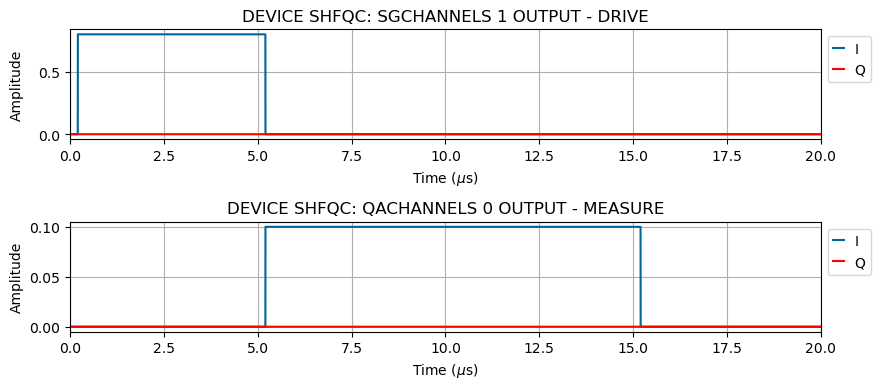

In [202]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)
plot_simulation(compiled_qspec, start_time=0, length=20e-6)

In [ ]:
qspec_results = session.run(compiled_qspec) 
timestamp = time.strftime("%Y%m%dT%H%M%S")

outdir = "qubit_results"
os.makedirs(outdir, exist_ok=True)

# --- Timestamp ---
timestamp = time.strftime("%Y%m%dT%H%M%S")

# Frequencies in Hz
freqs = qspec_results.acquired_results["qb_spec"].axis[0]

# Complex IQ data
iq_data = qspec_results.acquired_results["qb_spec"].data

# Separate real and imaginary parts
real_part = iq_data.real
imag_part = iq_data.imag

# --- Convert to dBm ---
def to_dbm(signal):
    power_W = (signal**2) / 50
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)  # avoid log(0)

amp_dbm = to_dbm(np.abs(iq_data))
real_dbm = to_dbm(real_part)
imag_dbm = to_dbm(imag_part)

# Phase (radians)
phase_rad = np.angle(iq_data)

freq_list = freqs + qb_lo_freq



[2025.08.24 19:44:06.971] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 19:44:06.974] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.24 19:44:06.978] INFO    Configuring the device setup
[2025.08.24 19:44:06.987] INFO    The device setup is configured
[2025.08.24 19:44:07.306] INFO    Starting near-time execution...
[2025.08.24 19:44:07.346] INFO    Estimated RT execution time: 190.86 s.


Saved figure to qubit_results\qubit_spectroscopy_Q4_20250824T194301.png
Saved data to qubit_results\qubit_spectroscopy_Q4_20250824T194301.csv


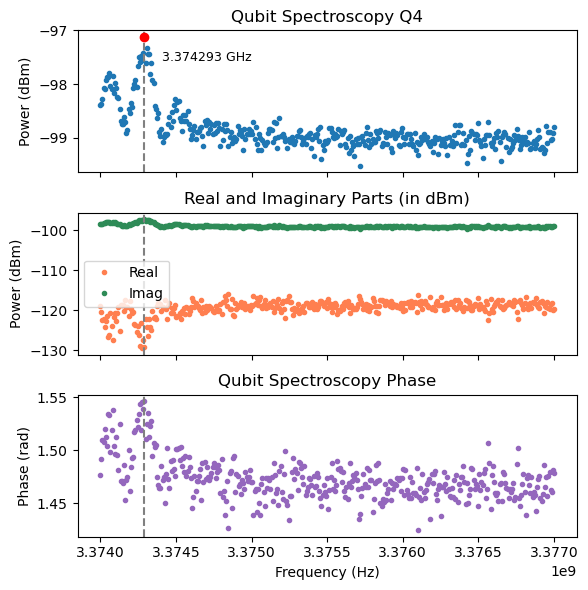

In [ ]:
# === Combined Figure ===
fig, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)  # portrait style

# --- Find max of overall amplitude and its frequency ---
max_idx = int(np.nanargmax(amp_dbm))
max_freq = float(freq_list[max_idx])  # Hz

# --- Subplot 1: Amplitude (dBm) ---
axs[0].plot(freq_list, amp_dbm, marker='o', linestyle="None", markersize=3)
axs[0].axvline(max_freq, color="gray", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Power (dBm)")
axs[0].set_title("Qubit Spectroscopy Q4")

# Mark the maximum point in red + label only frequency
axs[0].plot(max_freq, amp_dbm[max_idx], marker='o', color='red', markersize=6)
axs[0].annotate(
    f"{max_freq/1e9:.6f} GHz",
    xy=(max_freq, amp_dbm[max_idx]),
    xytext=(45, -10), textcoords="offset points",
    ha="center", va="top", fontsize=9
)

# --- Subplot 2: Real & Imag (dBm) ---
axs[1].plot(freq_list, real_dbm, label="Real", color="coral",
            marker='o', linestyle="None", markersize=3)
axs[1].plot(freq_list, imag_dbm, label="Imag", color="seagreen",
            marker='o', linestyle="None", markersize=3)
axs[1].axvline(max_freq, color="gray", linestyle="--", linewidth=1.5)
axs[1].set_ylabel("Power (dBm)")
axs[1].set_title("Real and Imaginary Parts (in dBm)")
axs[1].legend()

# --- Subplot 3: Phase (rad) ---
axs[2].plot(freq_list, phase_rad, color="tab:purple",
            marker='o', linestyle="None", markersize=3)
axs[2].axvline(max_freq, color="gray", linestyle="--", linewidth=1.5)
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Phase (rad)")
axs[2].set_title("Qubit Spectroscopy Phase")

plt.tight_layout()
# === Save figure with timestamp ===
fig_path = os.path.join(outdir, f"qubit_spectroscopy_Q4_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# === Save data as CSV with timestamp ===
df = pd.DataFrame({
    "Frequency_Hz": freq_list,
    "Amplitude_dBm": amp_dbm,
    "Real_dBm": real_dbm,
    "Imag_dBm": imag_dbm,
    "Phase_rad": phase_rad,
})
csv_path = os.path.join(outdir, f"qubit_spectroscopy_Q4_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()
